In [1]:
import numpy as np
from gpcam import GPOptimizer

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go

from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path

from sklearn.metrics import mean_squared_error

from sklearn import datasets, manifold

from sklearn.model_selection import train_test_split


In [2]:
# Convention:
#   X: Input in original Space
#   X_latent: Latent input
#   y: test function values

# def himmelblau(x, y):
#     x = x/10.
#     y = y/10.
#     return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# def my_2D_sinusoidal_func(x,y):
#     y = np.sin(0.1 * np.pi * x) + 0.3 * np.sin(0.5 * np.pi * y) + 3
#     return y

# def my_1D_sinusoidal_func(x):
#     y = np.sin(0.1 * np.pi * x) + 0.3 * np.sin(0.5 * np.pi * x) + 3
#     return y

# def my_1D_linear_func(x):
#     y = 1*x + 10
#     return y

def my3D_sinusoidal_func(x, y, z):
    result = (np.sin(0.1 * np.pi * x) + 
              0.3 * np.sin(0.5 * np.pi * y) + 
              0.25 * np.sin(0.4 * np.pi * z) + 
              0.99 * np.sin(0.2 * np.pi * x * y))
    return result

def my3D_linear_func(x, y, z):
    result = 1*x + 2*y + 3*z + 10
    return result


def my_2DS():
    n_samples = 1500
    S_points, S_color = datasets.make_s_curve(n_samples, random_state=0)
    return S_points, S_color

X, S_true_color = my_2DS()

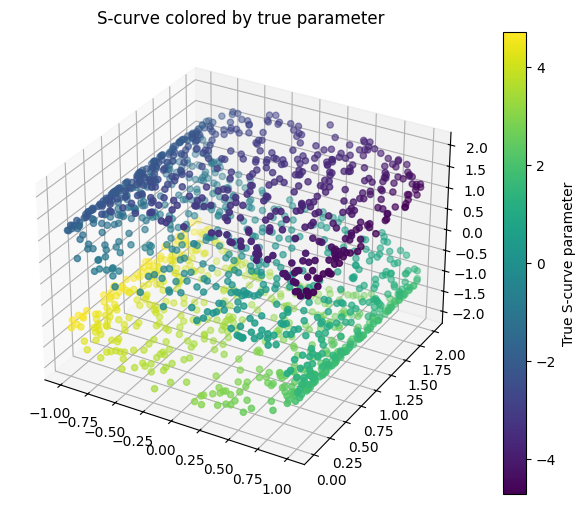

In [3]:
# Plotting the true S manifold and its true color metric.
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=S_true_color, cmap='viridis')
fig.colorbar(p, label='True S-curve parameter')
ax.set_title("S-curve colored by true parameter")
plt.show()

In [4]:
# 3D input

y = my3D_sinusoidal_func(X[:,0],X[:,1], X[:,2])

y = my3D_linear_func(X[:,0],X[:,1], X[:,2])


fig = go.Figure(data=[go.Scatter3d(
    x=X[:,0],y=X[:,1],z=X[:,2], mode='markers', marker=dict( size=5, color=y, colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

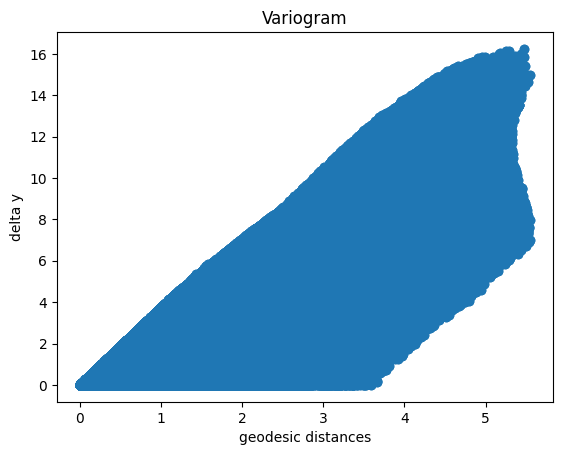

In [5]:
# Calculating the geodesic distance from the original Space

k = 200 #  Adjust as needed
W = kneighbors_graph(X, n_neighbors=k, mode='distance', include_self=False)

geo_dist_matrix_latent_space, predecessors = shortest_path(W, directed=False, return_predecessors=True)

my_delta_y = np.abs(np.subtract.outer(y,y))

plt.scatter(geo_dist_matrix_latent_space.flatten(),my_delta_y.flatten())
plt.xlabel("geodesic distances")
plt.ylabel("delta y")
plt.title("Variogram")
plt.show()

Text(0.5, 1.0, 'Kernel Matrix Heatmap')

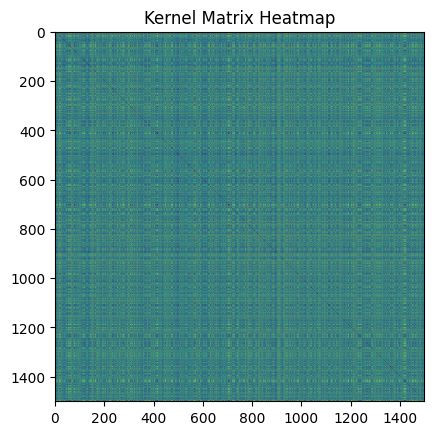

In [6]:
plt.imshow(geo_dist_matrix_latent_space)
plt.title('Kernel Matrix Heatmap')

In [7]:
# # Compute the half squared difference matrix
# my_delta_y2 = 0.5 * (np.subtract.outer(y, y)) ** 2

# # Plot the classical semi-variogram
# plt.scatter(geo_dist_matrix_latent_space.flatten(), my_delta_y2.flatten(), alpha=0.3, s=4)
# plt.xlabel('Geodesic distance (latent space)')
# plt.ylabel(r'$\frac{1}{2}(f(x_i) - f(x_j))^2$')
# plt.title('Empirical semi-variogram')
# plt.show()

# GP Model for Predicting the test function values (y)

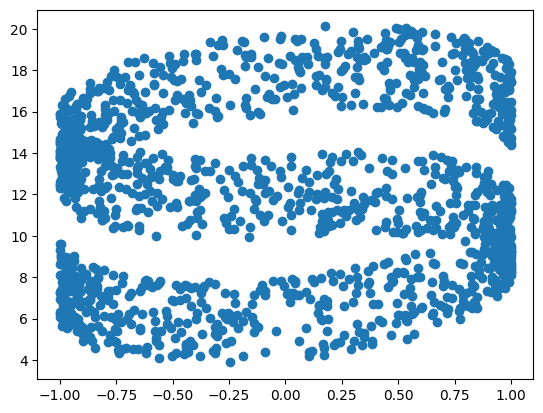

In [8]:
plt.scatter(X[:,0],y)

In [9]:
n_samples = 500

N = X.shape[0]

np.random.seed(1234)
# Randomly select 500 unique indices
indices = np.random.choice(N, size=n_samples, replace=False)

# Select test indices that do not overlap with train_indices
remaining_indices = np.setdiff1d(np.arange(N), indices)
test_indices = np.random.choice(remaining_indices, size=n_samples, replace=False)

# Extract the random set
x_data_gp = X[indices,:]
y_data_gp = y[indices]


# Extract the testing data
x_test = X[test_indices,:]
y_test = y[test_indices]


In [10]:
# Training data
fig = go.Figure(data=[go.Scatter3d(
    
    x=x_data_gp[:, 0], y=x_data_gp[:, 1], z=x_data_gp[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=y_data_gp,  # <-- use Himmelblau here!
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Test Function')
    )
)])

fig.update_layout(
    scene=dict(
        aspectmode='cube',
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
    ),
    width=600, height=600,
    margin=dict(r=30, b=20, l=20, t=20)
)
fig.show()

In [11]:
# testing data

fig = go.Figure(data=[go.Scatter3d(
    #x=X[indices, 0], y=X[indices, 1], z=X[indices, 2],
    x=x_test[:, 0], y=x_test[:, 1], z=x_test[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=y_test,  # <-- use Himmelblau here!
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Test Function')
    )
)])

fig.update_layout(
    scene=dict(
        aspectmode='cube',
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
    ),
    width=600, height=600,
    margin=dict(r=30, b=20, l=20, t=20)
)
fig.show()

In [12]:


#Noise Function
def my_noise(x,hps):
    my_s = np.ones(len(x))*hps[2]
    #noise = np.diag(my_s)
    return my_s

# Mean Function
def my_mean(x,hps):
    mean = np.ones(len(x))*hps[3]
    return mean


In [13]:
# #from gpcam.gp_kernels import *

# def bump(d, r, ampl):
#     """
#     evaluates the bump function
#     x ... a point (1d numpy array)
#     x0 ... 1d numpy array of location of bump function
#     returns the bump function b(x,x0) with radius r
#     """
#     #x_new = x - x0
#     #d = np.linalg.norm(x_new, axis = 1)
#     a = np.zeros(d.shape)
#     a = 1.0 - (d**2/r**2)
#     i = np.where(a > 0.0)
#     bump = np.zeros(a.shape)
#     beta = 0.1
#     e = np.exp((-beta/a[i])+beta)
#     bump[i] = ampl * e
#     return bump

# def get_distance_matrix(x1,x2):
#     d = np.zeros((len(x1),len(x2)))
#     for i in range(x1.shape[1]):
#         d += ((x1[:,i].reshape(-1, 1) - x2[:,i]))**2
#     return np.sqrt(d)


# def gb(x, hps):
#     # This returns all functions g_i (a g_i per data point) 
#     res = np.zeros((len(x),len(x_data)))
#     d = get_distance_matrix(x, x_data)
#     res = bump(d, hps/2., 1.)
#     return res

# def bump_kernel(x1, x2, hps):
#     gs1 = gb(x1, hps[1]).T
#     gs2 = gb(x2, hps[1]).T
#     G = gs1.T @ gs2
#     return 2.0 * hps[0] * G/float(len(x_data))  #maxG

In [14]:
def find_indices_ordered(x, x_data):
    matches = (x[:, None, :] == x_data[None, :, :]).all(axis=2)
    
    # Check if all points were found
    found = matches.any(axis=0)
    if not found.all():
        raise ValueError(f"Some points in x_data not found in x")
    
    indices_temp = np.argmax(matches, axis=0)
    return indices_temp


def bump(d, r, ampl):
    """
    evaluates the bump function
    x ... a point (1d numpy array)
    x0 ... 1d numpy array of location of bump function
    returns the bump function b(x,x0) with radius r
    """
    #x_new = x - x0
    #d = np.linalg.norm(x_new, axis = 1)
    a = np.zeros(d.shape)
    a = 1.0 - (d**2/r**2)
    i = np.where(a > 0.0)
    bump = np.zeros(a.shape)
    beta = 0.1
    e = np.exp((-beta/a[i])+beta)
    bump[i] = ampl * e
    return bump

# Precompute x_data_indices once (outside the kernel function)
x_data_indices_global = find_indices_ordered(X, x_data_gp)

def bump_kernel_geodesic_fast(x1, x2, hps):
    """Fast version of bump kernel"""
    # Find indices for x_data in X
    x1_indices = find_indices_ordered(X, x1)
    x2_indices = find_indices_ordered(X, x2)

    # Get geodesic distances (Use precomputed indices)
    d1 = geo_dist_matrix_latent_space[np.ix_(x1_indices, x_data_indices_global)]
    d2 = geo_dist_matrix_latent_space[np.ix_(x2_indices, x_data_indices_global)]
    
    # Compute bump functions
    gs1 = bump(d1, hps[1]/2., 1.).T
    gs2 = bump(d2, hps[1]/2., 1.).T
    
    G = gs1.T @ gs2
    return 2.0 * hps[0] * G/float(len(x_data_gp))

In [15]:
# Defining the bounds of hyperparameter optimization
bounds = np.empty((4,2))
# Kernel Sq Exp 
bounds[0] = np.array([1e-3,1000])   # signal variance      
bounds[1] = np.array([1e-2,100])   # kernel length for all input dimensions
# Noise
bounds[2] = np.array([1e-5,100]) 
# Mean
bounds[3] = np.array([np.min(y_data_gp),np.max(y_data_gp)])

init_hps = np.mean(bounds,axis=1)

my_gpo = GPOptimizer(x_data_gp,y_data_gp,
                     init_hyperparameters = init_hps,
                     kernel_function = bump_kernel_geodesic_fast,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                     )

my_gpo.train(hyperparameter_bounds = bounds, init_hyperparameters = init_hps, method='mcmc', max_iter = 4000)

print("GP Training Complete!")

my_gpo.get_hyperparameters()

GP Training Complete!


array([3.81506806e+02, 1.40086434e+01, 1.15870320e-01, 5.98557647e+00])

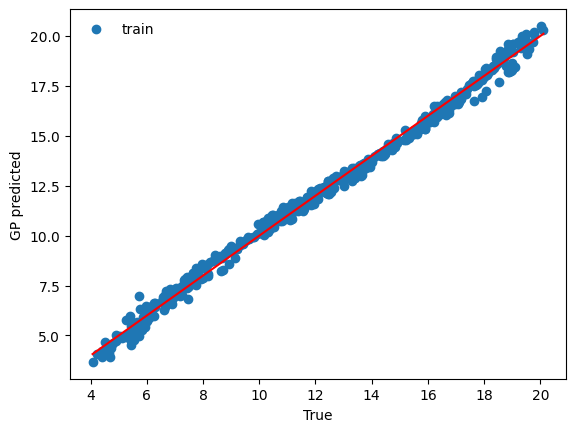

In [17]:
f_train = my_gpo.posterior_mean(x_data_gp)["m(x)"]

my_line = np.linspace(np.min(y_data_gp),np.max(y_data_gp),10)

plt.scatter(y_data_gp,f_train,label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [19]:
fig = go.Figure(data=[go.Scatter3d(
    
    x=x_data_gp[:, 0], y=x_data_gp[:, 1], z=x_data_gp[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=f_train,  # <-- use Himmelblau here!
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Test Function')
    )
)])

fig.update_layout(
    scene=dict(
        aspectmode='cube',
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
    ),
    width=600, height=600,
    margin=dict(r=30, b=20, l=20, t=20)
)
fig.show()

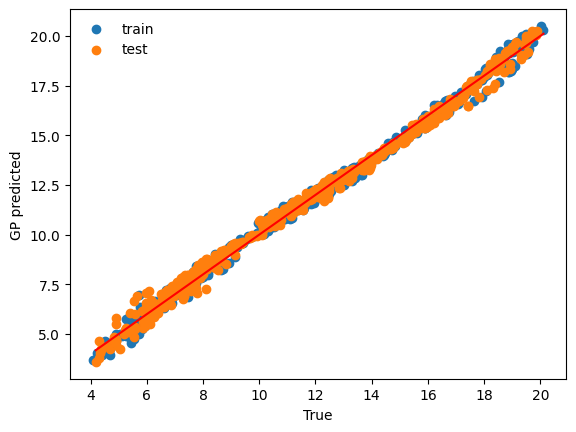

In [20]:
#x_pred = np.linspace(-30,40,100).reshape(-1,1)
#x_test_sorted = np.sort(x_test[:,0]).reshape(-1,1)
f = my_gpo.posterior_mean(x_test)["m(x)"]
f_train = my_gpo.posterior_mean(x_data_gp)["m(x)"]

# plt.scatter(x_test_sorted[:,0],f,c='blue')
# plt.scatter(x_data_gp,y_data_gp,c='red')
# plt.scatter(x_data_gp,f_train,c='magenta')

my_line = np.linspace(np.min(y_test),np.max(y_data_gp),10)

plt.scatter(y_data_gp,f_train,label = 'train')
plt.scatter(y_test,f,label = 'test')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [21]:
# RMSE and CRPS measures

my_rmse = my_gpo.rmse(x_test,y_test) * 100/ np.mean(y_test)
my_crps = my_gpo.crps(x_test,y_test)

print("RMSE is: ", my_rmse, "%")
print("CRPS is: ", my_crps)

RMSE is:  2.973084401824543 %
CRPS is:  (np.float64(0.2631753943313739), np.float64(0.19911379982229857))
